# SAR-Based Flood Inundation Mapping — Guwahati, Assam (2025 Monsoon)

**SAR + optical change detection for flood extent mapping using Google Earth Engine**

This notebook detects and maps flood inundation around the Guwahati / Brahmaputra
floodplain during the 2025 monsoon season by combining:

- **Sentinel-1 SAR** backscatter change detection (VV/VH, pre- vs post-event)
- **Sentinel-2 optical** NDWI change detection (cloud-masked)
- **JRC Global Surface Water** to exclude permanent water bodies
- **SAR × optical agreement** as a cross-validated inundation estimate

All outputs (figures, raster masks, and summary statistics) are saved to the
`outputs/` folder so they are available for review without re-running the
notebook.

> **Study area:** Guwahati / Brahmaputra floodplain, Assam, India
> **Study period:** May – September 2025
> **Platform:** Google Earth Engine (Python API) + `geemap`


## How this notebook is organized

1. Environment setup & output folders
2. Earth Engine authentication
3. Configuration (AOI, dates, thresholds — edit these to reuse the notebook elsewhere)
4. Sentinel-1 data discovery
5. AOI definition & candidate scene search
6. Temporal backscatter profile
7. Orbit / track selection (to keep geometry consistent between dates)
8. Pre-/post-/later-event scene selection
9. SAR change detection (ΔVV, ΔVH)
10. Speckle filtering & flood candidate mask
11. Permanent-water removal (JRC Global Surface Water)
12. Sentinel-2 NDWI optical change detection (cloud-masked)
13. SAR × optical cross-validation
14. Flood area statistics
15. Summary & saved outputs


## 1. Environment Setup

In [1]:
# Install required packages (safe to re-run; skips if already installed)
!pip -q install earthengine-api geemap pandas matplotlib requests pillow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.12.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.36.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
from pathlib import Path

import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

print("Earth Engine API:", ee.__version__)

# ---- Output folders -------------------------------------------------
# All figures, exported rasters, and summary tables are written here so
# the results are preserved alongside the notebook in version control.
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
RASTER_DIR = OUTPUT_DIR / "rasters"
RESULTS_DIR = OUTPUT_DIR / "results"

for d in (FIG_DIR, RASTER_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Output folders ready:")
for d in (FIG_DIR, RASTER_DIR, RESULTS_DIR):
    print(" -", d.resolve())

c:\Python310\lib\site-packages\google\api_core\_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Python310\lib\site-packages\google\api_core\_python_package_support.py:206: FutureWarning: Package google.api_core depends on grpcio, currently installed at version 1.59.0. grpcio < 1.83.0 does not support Post-Quantum Cryptography (PQC). Support for non-PQC environments is deprecated. In October 2026, Google Cloud Python packages will raise their minimum requirements (including google-api-core, grpcio, and grpcio-status) to enforce grpcio >= 1.83.0. For more details on Google Cloud's post-quantum security migration, visit: https://cloud.google.com/security/resource

Earth Engine API: 1.7.41
Output folders ready:
 - C:\Users\arpan\OneDrive\Desktop\PLACEMENT\Guwahati_SAR_project\outputs\figures
 - C:\Users\arpan\OneDrive\Desktop\PLACEMENT\Guwahati_SAR_project\outputs\rasters
 - C:\Users\arpan\OneDrive\Desktop\PLACEMENT\Guwahati_SAR_project\outputs\results


## 2. Earth Engine Authentication

Running this notebook requires a **Google Earth Engine account** with a
**Cloud project that has the Earth Engine API enabled**
(free — sign up at <https://earthengine.google.com>).

- The first time you run this cell, a browser window will open asking you to
  sign in and authorize Earth Engine. This is a **one-time** step per machine
  (credentials are cached locally).
- Set `EE_PROJECT` in the **Configuration** cell below to your own GEE Cloud
  project ID before running.


In [3]:
def initialize_earth_engine(project_id: str):
    """Authenticate (only if needed) and initialize the Earth Engine API."""
    try:
        ee.Initialize(project=project_id)
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=project_id)
    print("Earth Engine initialized successfully! Project:", project_id)

## 3. Configuration

Every parameter that defines *this specific analysis* (AOI, dates, orbit,
thresholds) lives here. Change these values to re-run the same pipeline for
a different flood event, location, or date range.


In [4]:
# ============================================================
# CONFIGURATION — edit for your own project / AOI / event
# ============================================================

# Your Google Earth Engine Cloud project ID
EE_PROJECT = "sar-change-analysis"          # <-- change to your own GEE project

# Area of interest: [minLon, minLat, maxLon, maxLat]
# Default: Guwahati / Brahmaputra floodplain, Assam, India
AOI_BOUNDS = [91.55, 26.05, 91.95, 26.35]

# Full study window used for scene discovery / temporal profiling
STUDY_START, STUDY_END = "2025-05-01", "2025-09-30"

# Sentinel-1 relative orbit to lock geometry/incidence angle across dates
RELATIVE_ORBIT = 150

# SAR acquisition dates used for change detection (pre / post / later)
PRE_DATE   = ("2025-05-26", "2025-05-27")
POST_DATE  = ("2025-06-07", "2025-06-08")
LATER_DATE = ("2025-07-13", "2025-07-14")

# Sentinel-2 acquisition dates used for optical NDWI change detection
S2_PRE_DATE  = ("2025-05-10", "2025-05-11")
S2_POST_DATE = ("2025-06-09", "2025-06-10")
S2_CLOUD_MAX = 25  # max CLOUDY_PIXEL_PERCENTAGE

# SAR change-detection thresholds (dB) — from the ΔVV/ΔVH percentile analysis
VV_THRESHOLD = -5.24
VH_THRESHOLD = -6.24

# Optical NDWI water threshold
NDWI_THRESHOLD = 0.2

# Permanent-water threshold (JRC occurrence %, pixels >= this are excluded)
JRC_PERMANENT_WATER_THRESHOLD = 90

initialize_earth_engine(EE_PROJECT)

aoi = ee.Geometry.Rectangle(AOI_BOUNDS)


Successfully saved authorization token.
Earth Engine initialized successfully! Project: sar-change-analysis


In [5]:
def save_ee_thumbnail(image, vis_params, region, filename, dimensions=800):
    """Fetch a static PNG thumbnail of an EE image and save it to FIG_DIR.

    This works without Google Drive export permissions and is the simplest
    way to persist a snapshot of an interactive geemap layer as a figure.
    """
    url = image.getThumbURL({
        **vis_params,
        "region": region,
        "dimensions": dimensions,
        "format": "png",
    })
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))
    out_path = FIG_DIR / filename
    img.save(out_path)
    print("Saved figure:", out_path)
    return out_path


def export_ee_geotiff(image, filename, region, scale=20):
    """Export an EE image to a local GeoTIFF (direct download, no Drive needed)."""
    out_path = RASTER_DIR / filename
    geemap.ee_export_image(
        image,
        filename=str(out_path),
        scale=scale,
        region=region,
        file_per_band=False,
    )
    return out_path

## 4. Sentinel-1 Data Discovery

Sanity-check the Sentinel-1 GRD collection and confirm which acquisition
modes and orbit passes are available over the study period.


In [6]:
s1 = ee.ImageCollection("COPERNICUS/S1_GRD")

print("Sentinel-1 collection:")
print(s1.limit(1).getInfo())

Sentinel-1 collection:
{'type': 'ImageCollection', 'bands': [], 'version': 1787610278176501, 'id': 'COPERNICUS/S1_GRD', 'features': [{'type': 'Image', 'bands': [{'id': 'HH', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'dimensions': [28690, 24380], 'crs': 'EPSG:32649', 'crs_transform': [25, 0, 121126.54059585743, 0, -25, 9304939.230889248]}, {'id': 'HV', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'dimensions': [28690, 24380], 'crs': 'EPSG:32649', 'crs_transform': [25, 0, 121126.54059585743, 0, -25, 9304939.230889248]}, {'id': 'angle', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'dimensions': [21, 23], 'crs': 'EPSG:32649', 'crs_transform': [-17767.32741268468, -10569.533829640946, 751271.487822352, 10727.60234561935, -17439.323301551864, 9066467.508126782]}], 'version': 1787610278176501, 'id': 'COPERNICUS/S1_GRD/S1A_EW_GRDH_1SDH_20141003T003636_20141003T003740_002658_002F54_ECFA', 'properties': {'SNAP_Graph_Processing_Framework_GPF_vers': '6.0

In [7]:
s1_year = s1.filterDate(f"{STUDY_START[:4]}-01-01", f"{int(STUDY_START[:4]) + 1}-01-01")
print("Number of Sentinel-1 images in", STUDY_START[:4] + ":", s1_year.size().getInfo())

Number of Sentinel-1 images in 2025: 369363


In [8]:
print(
    s1_year.aggregate_array("instrumentMode")
      .distinct()
      .getInfo()
)

['EW', 'IW', 'SM']


In [9]:
print(
    s1_year.aggregate_array("orbitProperties_pass")
      .distinct()
      .getInfo()
)

['DESCENDING', 'ASCENDING']


## 5. AOI Definition & Candidate Scene Search

Filter Sentinel-1 to IW mode, VV polarization, descending pass, over the AOI
and study window.


In [10]:
s1_assam = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate(STUDY_START, STUDY_END)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
    .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING"))
)

print("Candidate scenes:", s1_assam.size().getInfo())

Candidate scenes: 25


## 6. Scene Date Inspection

In [11]:
dates = (
    s1_assam
    .aggregate_array("system:time_start")
    .getInfo()
)

dates = pd.to_datetime(dates, unit="ms").sort_values()

print("First 10:")
print(dates[:10])

print("\nLast 10:")
print(dates[-10:])

First 10:
DatetimeIndex(['2025-05-02 23:55:35', '2025-05-09 23:47:18',
               '2025-05-14 23:55:35', '2025-05-21 23:47:17',
               '2025-05-26 23:55:34', '2025-06-02 23:47:17',
               '2025-06-07 23:55:34', '2025-07-08 23:47:15',
               '2025-07-13 23:55:32', '2025-07-20 23:47:14'],
              dtype='datetime64[ns]', freq=None)

Last 10:
DatetimeIndex(['2025-08-18 23:55:22', '2025-08-25 23:47:04',
               '2025-08-25 23:47:29', '2025-08-30 23:55:22',
               '2025-09-06 23:47:04', '2025-09-06 23:47:29',
               '2025-09-11 23:55:22', '2025-09-18 23:47:05',
               '2025-09-18 23:47:30', '2025-09-23 23:55:22'],
              dtype='datetime64[ns]', freq=None)


## 7. Temporal Backscatter Profile

Build 2-week VV backscatter composites across the study period. A sharp,
sustained drop in mean VV backscatter is a first-order signal of surface
inundation (open water is a specular reflector and appears very dark to SAR).


In [12]:
# 2-week temporal composites across the study window
periods = [
    ("2025-05-01", "2025-05-15"),
    ("2025-05-15", "2025-06-01"),
    ("2025-06-01", "2025-06-15"),
    ("2025-06-15", "2025-07-01"),
    ("2025-07-01", "2025-07-15"),
    ("2025-07-15", "2025-08-01"),
    ("2025-08-01", "2025-08-15"),
    ("2025-08-15", "2025-09-01"),
    ("2025-09-01", "2025-09-30"),
]

temporal_stats = []

for start, end in periods:

    collection = s1_assam.filterDate(start, end)
    count = collection.size().getInfo()

    if count > 0:
        stats = collection.select("VV").median().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=1000,
            maxPixels=1e9
        ).getInfo()

        temporal_stats.append({
            "start": start,
            "end": end,
            "images": count,
            "mean_VV_dB": stats.get("VV")
        })

df = pd.DataFrame(temporal_stats)
print(df)

# Save the backscatter time series for the record
df.to_csv(RESULTS_DIR / "temporal_vv_backscatter.csv", index=False)
print("Saved:", RESULTS_DIR / "temporal_vv_backscatter.csv")

        start         end  images  mean_VV_dB
0  2025-05-01  2025-05-15       3   -7.708211
1  2025-05-15  2025-06-01       2   -7.501086
2  2025-06-01  2025-06-15       2   -8.029248
3  2025-07-01  2025-07-15       2   -8.108557
4  2025-07-15  2025-08-01       2   -8.153929
5  2025-08-01  2025-08-15       4   -8.084018
6  2025-08-15  2025-09-01       4   -7.803337
7  2025-09-01  2025-09-30       6   -8.195200
Saved: outputs\results\temporal_vv_backscatter.csv


Saved: outputs\figures\temporal_vv_backscatter.png


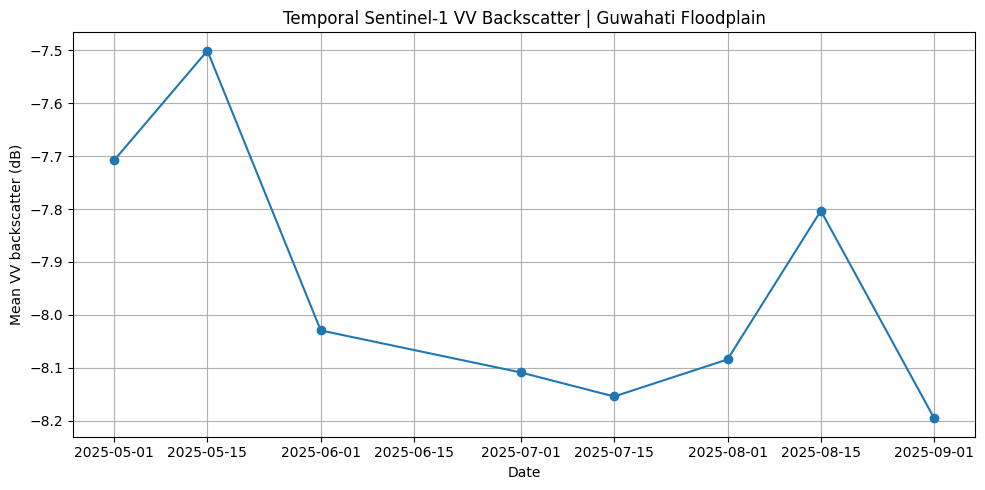

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    pd.to_datetime(df["start"]),
    df["mean_VV_dB"],
    marker="o"
)

ax.set_xlabel("Date")
ax.set_ylabel("Mean VV backscatter (dB)")
ax.set_title("Temporal Sentinel-1 VV Backscatter | Guwahati Floodplain")
ax.grid(True)

fig.tight_layout()
fig.savefig(FIG_DIR / "temporal_vv_backscatter.png", dpi=150)
print("Saved:", FIG_DIR / "temporal_vv_backscatter.png")
plt.show()

## 8. Orbit / Track Selection

SAR backscatter is sensitive to viewing geometry, so pre/post images must
come from the **same relative orbit** for a clean change-detection signal.
This step inspects which relative orbits are available and how consistently
they're acquired.


In [14]:
info = s1_assam.getInfo()

rows = []

for feature in info["features"]:
    p = feature["properties"]

    rows.append({
        "date": pd.to_datetime(p["system:time_start"], unit="ms"),
        "relative_orbit": p.get("relativeOrbitNumber_start"),
        "pass": p.get("orbitProperties_pass"),
        "platform": p.get("platform_number"),
        "mode": p.get("instrumentMode")
    })

orbit_df = pd.DataFrame(rows).sort_values("date")
print(orbit_df.to_string(index=False))

orbit_df.to_csv(RESULTS_DIR / "s1_orbit_metadata.csv", index=False)
print("\nSaved:", RESULTS_DIR / "s1_orbit_metadata.csv")

               date  relative_orbit       pass platform mode
2025-05-02 23:55:35             150 DESCENDING        A   IW
2025-05-09 23:47:18              77 DESCENDING        A   IW
2025-05-14 23:55:35             150 DESCENDING        A   IW
2025-05-21 23:47:17              77 DESCENDING        A   IW
2025-05-26 23:55:34             150 DESCENDING        A   IW
2025-06-02 23:47:17              77 DESCENDING        A   IW
2025-06-07 23:55:34             150 DESCENDING        A   IW
2025-07-08 23:47:15              77 DESCENDING        A   IW
2025-07-13 23:55:32             150 DESCENDING        A   IW
2025-07-20 23:47:14              77 DESCENDING        A   IW
2025-07-25 23:55:32             150 DESCENDING        A   IW
2025-08-01 23:47:15              77 DESCENDING        A   IW
2025-08-06 23:55:22             150 DESCENDING        A   IW
2025-08-13 23:47:04              77 DESCENDING        A   IW
2025-08-13 23:47:29              77 DESCENDING        A   IW
2025-08-18 23:55:22     

In [15]:
print("\nRelative orbit numbers:")
print(orbit_df["relative_orbit"].value_counts())

print("\nPlatform:")
print(orbit_df["platform"].value_counts())

print("\nPass:")
print(orbit_df["pass"].value_counts())


Relative orbit numbers:
relative_orbit
77     14
150    11
Name: count, dtype: int64

Platform:
platform
A    25
Name: count, dtype: int64

Pass:
pass
DESCENDING    25
Name: count, dtype: int64


## 9. Fixed-Orbit Scene Search

Restrict to the `RELATIVE_ORBIT` set in Configuration so every date shares the same acquisition geometry.

In [16]:
orbit_fixed = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING"))
    .filter(ee.Filter.eq("relativeOrbitNumber_start", RELATIVE_ORBIT))
    .filter(ee.Filter.listContains(
        "transmitterReceiverPolarisation", "VV"
    ))
)

print(f"Orbit {RELATIVE_ORBIT} scenes:", orbit_fixed.size().getInfo())

print(
    orbit_fixed
    .aggregate_array("system:time_start")
    .getInfo()
)

Orbit 150 scenes: 350
[1413417268600, 1413417297520, 1415490868320, 1415490897250, 1417564467730, 1417564496650, 1419638066880, 1419638095800, 1421711666150, 1421711695070, 1423785265270, 1423785294180, 1425858865790, 1425858894710, 1427932466240, 1427932495150, 1430006067450, 1430006096350, 1432079668770, 1432079697660, 1434153270470, 1434153299360, 1436226870690, 1436226899590, 1440374073600, 1440374102520, 1444521274890, 1444521303800, 1448668497690, 1450742096840, 1454889295460, 1456962895450, 1461110096770, 1463183671840, 1463183700870, 1465257273090, 1465257302130, 1467330874490, 1467330903500, 1469404475770, 1469404504800, 1471478077130, 1471478106150, 1473551678060, 1473551707080, 1475625278590, 1475625307600, 1477698878000, 1477698907790, 1479772478370, 1479772507380, 1481846077000, 1481846106520, 1483919675000, 1483919704000, 1485993275000, 1485993304000, 1488066883000, 1488066908020, 1489103683000, 1489103708090, 1490140500370, 1491177300810, 1492214101330, 1493250901000, 14

## 10. Pre-/Post-/Later-Event Scene Selection

In [17]:
s1_2025 = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(aoi)
    .filterDate(STUDY_START, "2025-08-01")
    .filter(ee.Filter.eq("instrumentMode", "IW"))
    .filter(ee.Filter.eq("orbitProperties_pass", "DESCENDING"))
    .filter(ee.Filter.eq("relativeOrbitNumber_start", RELATIVE_ORBIT))
    .filter(ee.Filter.listContains(
        "transmitterReceiverPolarisation", "VV"
    ))
)

print(f"Orbit {RELATIVE_ORBIT} scenes in study period:", s1_2025.size().getInfo())

Orbit 150 scenes in study period: 6


In [18]:
pre = s1_2025.filterDate(*PRE_DATE).first()
post = s1_2025.filterDate(*POST_DATE).first()
later = s1_2025.filterDate(*LATER_DATE).first()

print("Pre-event :", pre.get("system:index").getInfo())
print("Post-event:", post.get("system:index").getInfo())
print("Later     :", later.get("system:index").getInfo())

Pre-event : S1A_IW_GRDH_1SDV_20250526T235534_20250526T235559_059372_075E87_8E7D
Post-event: S1A_IW_GRDH_1SDV_20250607T235534_20250607T235559_059547_07648A_CFA3
Later     : S1A_IW_GRDH_1SDV_20250713T235532_20250713T235557_060072_0776A9_D187


In [19]:
metadata_fields = [
    "system:time_start",
    "relativeOrbitNumber_start",
    "orbitProperties_pass",
    "instrumentMode",
    "platform_number",
]

pre_meta = pre.toDictionary(metadata_fields).getInfo()
post_meta = post.toDictionary(metadata_fields).getInfo()
print(pre_meta)
print(post_meta)

{'instrumentMode': 'IW', 'orbitProperties_pass': 'DESCENDING', 'platform_number': 'A', 'relativeOrbitNumber_start': 150, 'system:time_start': 1748303734000}
{'instrumentMode': 'IW', 'orbitProperties_pass': 'DESCENDING', 'platform_number': 'A', 'relativeOrbitNumber_start': 150, 'system:time_start': 1749340534000}


## 11. SAR Change Detection (ΔVV, ΔVH)

Clip each scene to the AOI and compute the pre→post (and pre→later, for
context) backscatter difference in both polarizations.


In [20]:
pre_vv = pre.select("VV").clip(aoi)
post_vv = post.select("VV").clip(aoi)
later_vv = later.select("VV").clip(aoi)

pre_vh = pre.select("VH").clip(aoi)
post_vh = post.select("VH").clip(aoi)
later_vh = later.select("VH").clip(aoi)

# VV changes
delta_vv_early = post_vv.subtract(pre_vv).rename("delta_VV")
delta_vv_later = later_vv.subtract(pre_vv).rename("delta_VV_later")

# VH changes
delta_vh_early = post_vh.subtract(pre_vh).rename("delta_VH")
delta_vh_later = later_vh.subtract(pre_vh).rename("delta_VH_later")

### Interactive map: pre/post VV and ΔVV

In [21]:
Map = geemap.Map()
Map.centerObject(aoi, 11)

vv_vis = {"min": -25, "max": 5}
change_vis = {
    "min": -6, "max": 6,
    "palette": ["0000ff", "ffffff", "ff0000"],
}

Map.addLayer(pre_vv, vv_vis, "01 - VV | pre-event")
Map.addLayer(post_vv, vv_vis, "02 - VV | post-event", False)
Map.addLayer(later_vv, vv_vis, "03 - VV | later", False)
Map.addLayer(delta_vv_early, change_vis, "04 - \u0394VV | post - pre", False)
Map.addLayer(delta_vh_early, change_vis, "05 - \u0394VH | post - pre", False)
Map.addLayer(aoi, {}, "Study Area", False)
Map

Map(center=[26.200073868548518, 91.7500000000005], controls=(WidgetControl(options=['position', 'transparent_b…

In [22]:
# Save static snapshots of the key SAR layers for the report / README
save_ee_thumbnail(pre_vv, vv_vis, aoi, "01_vv_pre_event.png")
save_ee_thumbnail(post_vv, vv_vis, aoi, "02_vv_post_event.png")
save_ee_thumbnail(delta_vv_early, change_vis, aoi, "03_delta_vv_post_minus_pre.png")
save_ee_thumbnail(delta_vh_early, change_vis, aoi, "04_delta_vh_post_minus_pre.png")

Saved figure: outputs\figures\01_vv_pre_event.png
Saved figure: outputs\figures\02_vv_post_event.png
Saved figure: outputs\figures\03_delta_vv_post_minus_pre.png
Saved figure: outputs\figures\04_delta_vh_post_minus_pre.png


WindowsPath('outputs/figures/04_delta_vh_post_minus_pre.png')

In [23]:
# Percentile summary of the raw change layers — used to pick thresholds
def get_percentiles(image, name):
    result = image.reduceRegion(
        reducer=ee.Reducer.percentile(
            [1, 5, 10, 25, 50, 75, 90, 95, 99]
        ),
        geometry=aoi,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    print(f"\n{name}")
    for key, value in result.items():
        print(f"{key}: {value:.3f}")

    return {"layer": name, **result}


percentile_rows = [
    get_percentiles(delta_vv_early, "\u0394VV | post - pre"),
    get_percentiles(delta_vh_early, "\u0394VH | post - pre"),
    get_percentiles(delta_vv_later, "\u0394VV | later - pre"),
    get_percentiles(delta_vh_later, "\u0394VH | later - pre"),
]

pd.DataFrame(percentile_rows).to_csv(
    RESULTS_DIR / "delta_backscatter_percentiles.csv", index=False
)
print("\nSaved:", RESULTS_DIR / "delta_backscatter_percentiles.csv")


ΔVV | post - pre
delta_VV_p1: -14.247
delta_VV_p10: -5.242
delta_VV_p25: -2.741
delta_VV_p5: -7.747
delta_VV_p50: -0.749
delta_VV_p75: 1.243
delta_VV_p90: 2.741
delta_VV_p95: 4.236
delta_VV_p99: 7.744

ΔVH | post - pre
delta_VH_p1: -16.246
delta_VH_p10: -6.241
delta_VH_p25: -2.745
delta_VH_p5: -9.242
delta_VH_p50: -0.750
delta_VH_p75: 1.244
delta_VH_p90: 3.239
delta_VH_p95: 4.239
delta_VH_p99: 8.751

ΔVV | later - pre
delta_VV_later_p1: -9.243
delta_VV_later_p10: -4.240
delta_VV_later_p25: -2.246
delta_VV_later_p5: -5.737
delta_VV_later_p50: -0.251
delta_VV_later_p75: 1.742
delta_VV_later_p90: 4.243
delta_VV_later_p95: 7.246
delta_VV_later_p99: 12.243

ΔVH | later - pre
delta_VH_later_p1: -12.745
delta_VH_later_p10: -5.241
delta_VH_later_p25: -2.746
delta_VH_later_p5: -6.739
delta_VH_later_p50: -0.751
delta_VH_later_p75: 1.245
delta_VH_later_p90: 3.740
delta_VH_later_p95: 5.237
delta_VH_later_p99: 10.736

Saved: outputs\results\delta_backscatter_percentiles.csv


## 12. Speckle Filtering & Flood Candidate Mask

Apply a focal-median speckle filter, then threshold ΔVV and ΔVH using values
derived from the percentile analysis above (both bands must drop, which
reduces false positives from single-polarization noise).


In [24]:
delta_vv_filtered = delta_vv_early.focal_median(
    radius=30, units="meters"
).rename("delta_VV_filtered")

delta_vh_filtered = delta_vh_early.focal_median(
    radius=30, units="meters"
).rename("delta_VH_filtered")

In [25]:
filtered_vis = {
    "min": -5, "max": 5,
    "palette": ["0000ff", "ffffff", "ff0000"],
}

save_ee_thumbnail(delta_vv_filtered, filtered_vis, aoi, "05_delta_vv_filtered.png")
save_ee_thumbnail(delta_vh_filtered, filtered_vis, aoi, "06_delta_vh_filtered.png")

Saved figure: outputs\figures\05_delta_vv_filtered.png
Saved figure: outputs\figures\06_delta_vh_filtered.png


WindowsPath('outputs/figures/06_delta_vh_filtered.png')

In [26]:
flood_candidate = (
    delta_vv_early.lt(VV_THRESHOLD)
    .And(delta_vh_early.lt(VH_THRESHOLD))
).rename("flood_candidate")

print("Flood candidate mask created "
      f"(VV < {VV_THRESHOLD} dB AND VH < {VH_THRESHOLD} dB).")

Flood candidate mask created (VV < -5.24 dB AND VH < -6.24 dB).


In [27]:
# Morphological open (max then min) to remove speckle-scale false positives
flood_clean = (
    flood_candidate
    .focal_max(radius=30, units="meters")
    .focal_min(radius=30, units="meters")
    .rename("flood_candidate_clean")
)

print("Spatial filtering completed.")

Spatial filtering completed.


In [28]:
Map2 = geemap.Map()
Map2.centerObject(aoi, 11)

Map2.addLayer(
    flood_clean.selfMask(),
    {"palette": ["0000FF"], "opacity": 0.8},
    "SAR Flood Candidate (cleaned)"
)
Map2.addLayer(aoi, {"color": "red"}, "AOI", False)
Map2

Map(center=[26.200073868548518, 91.74999999999949], controls=(WidgetControl(options=['position', 'transparent_…

In [29]:
save_ee_thumbnail(
    flood_clean.selfMask(), {"palette": ["0000FF"]}, aoi,
    "07_sar_flood_candidate_clean.png"
)

Saved figure: outputs\figures\07_sar_flood_candidate_clean.png


WindowsPath('outputs/figures/07_sar_flood_candidate_clean.png')

## 13. Permanent-Water Removal (JRC Global Surface Water)

Rivers, lakes, and other permanent water bodies would otherwise be flagged
as "flooded". Mask out any pixel with high historical water occurrence.


In [30]:
jrc = ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
occurrence = jrc.select("occurrence")

permanent_water = occurrence.gte(JRC_PERMANENT_WATER_THRESHOLD)

flood_candidate_land = flood_clean.And(
    permanent_water.Not()
).rename("candidate_inundation")

In [31]:
Map3 = geemap.Map()
Map3.centerObject(aoi, 11)

Map3.addLayer(
    flood_candidate_land.selfMask(),
    {"palette": ["0000FF"], "opacity": 0.8},
    "SAR Candidate Inundation (permanent water removed)"
)
Map3.addLayer(aoi, {"color": "red"}, "AOI", False)
Map3

Map(center=[26.200073868548518, 91.74999999999949], controls=(WidgetControl(options=['position', 'transparent_…

In [32]:
save_ee_thumbnail(
    flood_candidate_land.selfMask(), {"palette": ["0000FF"]}, aoi,
    "08_sar_candidate_inundation.png"
)

export_ee_geotiff(
    flood_candidate_land.selfMask().toByte(),
    "sar_flood_mask.tif",
    region=aoi,
    scale=20,
)

Saved figure: outputs\figures\08_sar_candidate_inundation.png
Generating URL ...
Please wait ...
Data downloaded to c:\Users\arpan\OneDrive\Desktop\PLACEMENT\Guwahati_SAR_project\outputs\rasters\sar_flood_mask.tif


WindowsPath('outputs/rasters/sar_flood_mask.tif')

## 14. Sentinel-2 NDWI Optical Change Detection

Independently estimate flooded area from optical imagery (NDWI) as a
cross-check on the SAR-derived mask. Scenes are searched around the same
pre-/post-event window and filtered for cloud cover; cloud/shadow pixels are
masked using the Scene Classification Layer (SCL) before computing NDWI.


In [33]:
def add_ndwi(image):
    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")
    return image.addBands(ndwi)


def mask_s2_clouds(image):
    """Mask cloud, cloud-shadow, cirrus, and snow/ice pixels using SCL."""
    scl = image.select("SCL")
    # Remove: 3 = cloud shadow, 8/9 = cloud, 10 = cirrus, 11 = snow/ice
    mask = (
        scl.neq(3)
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )
    return image.updateMask(mask)

In [34]:
# Check scene availability / cloud cover around the target dates, to
# justify the specific pre/post dates chosen in the Configuration cell.
s2_raw = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2025-05-15", "2025-06-15")
)

print("Total Sentinel-2 scenes:", s2_raw.size().getInfo())

info = s2_raw.toList(s2_raw.size())
n = s2_raw.size().getInfo()
rows = []
for i in range(n):
    img = ee.Image(info.get(i))
    date = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd").getInfo()
    cloud = img.get("CLOUDY_PIXEL_PERCENTAGE").getInfo()
    rows.append({"date": date, "cloud_pct": round(cloud, 2)})
    print(date, "| cloud =", round(cloud, 2), "%")

pd.DataFrame(rows).to_csv(RESULTS_DIR / "s2_scene_cloud_cover.csv", index=False)
print("\nSaved:", RESULTS_DIR / "s2_scene_cloud_cover.csv")

Total Sentinel-2 scenes: 18
2025-05-15 | cloud = 100.0 %
2025-05-15 | cloud = 99.97 %
2025-05-15 | cloud = 100.0 %
2025-05-15 | cloud = 100.0 %
2025-05-20 | cloud = 100.0 %
2025-05-20 | cloud = 99.85 %
2025-05-25 | cloud = 83.98 %
2025-05-25 | cloud = 99.51 %
2025-05-30 | cloud = 100.0 %
2025-05-30 | cloud = 99.99 %
2025-06-01 | cloud = 100.0 %
2025-06-01 | cloud = 98.02 %
2025-06-04 | cloud = 100.0 %
2025-06-04 | cloud = 99.99 %
2025-06-09 | cloud = 30.92 %
2025-06-09 | cloud = 21.03 %
2025-06-14 | cloud = 59.25 %
2025-06-14 | cloud = 47.24 %

Saved: outputs\results\s2_scene_cloud_cover.csv


In [35]:
s2_pre = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(*S2_PRE_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", S2_CLOUD_MAX))
    .sort("CLOUDY_PIXEL_PERCENTAGE")
    .first()
)

s2_post = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(*S2_POST_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", S2_CLOUD_MAX))
    .sort("CLOUDY_PIXEL_PERCENTAGE")
    .first()
)

s2_pre = add_ndwi(mask_s2_clouds(s2_pre))
s2_post = add_ndwi(mask_s2_clouds(s2_post))

print("Pre image :", s2_pre.get("system:index").getInfo())
print("Post image:", s2_post.get("system:index").getInfo())

Pre image : 20250510T042721_20250510T043037_T46RCP
Post image: 20250609T042721_20250609T043056_T46RCQ


In [36]:
ndwi_pre = s2_pre.select("NDWI")
ndwi_post = s2_post.select("NDWI")

delta_ndwi = ndwi_post.subtract(ndwi_pre).rename("delta_NDWI")

In [37]:
Map6 = geemap.Map()
Map6.centerObject(aoi, 11)

ndwi_change_vis = {"min": -0.5, "max": 0.5, "palette": ["red", "white", "blue"]}
Map6.addLayer(delta_ndwi, ndwi_change_vis, "Cloud-masked \u0394NDWI")
Map6

Map(center=[26.200073868548518, 91.74999999999949], controls=(WidgetControl(options=['position', 'transparent_…

In [38]:
save_ee_thumbnail(delta_ndwi, ndwi_change_vis, aoi, "09_delta_ndwi_cloud_masked.png")

ndwi_stats = delta_ndwi.reduceRegion(
    reducer=ee.Reducer.percentile([1, 5, 10, 25, 50, 75, 90, 95, 99]),
    geometry=aoi,
    scale=20,
    bestEffort=True,
    maxPixels=1e8,
).getInfo()

print(ndwi_stats)
with open(RESULTS_DIR / "delta_ndwi_percentiles.json", "w") as f:
    json.dump(ndwi_stats, f, indent=2)
print("Saved:", RESULTS_DIR / "delta_ndwi_percentiles.json")

Saved figure: outputs\figures\09_delta_ndwi_cloud_masked.png
{'delta_NDWI_p1': -0.3978993306664727, 'delta_NDWI_p10': -0.24185170202684064, 'delta_NDWI_p25': -0.19519892030629246, 'delta_NDWI_p5': -0.28870974820296885, 'delta_NDWI_p50': -0.10158026821550073, 'delta_NDWI_p75': -0.023677886981674494, 'delta_NDWI_p90': 0.10137304566944261, 'delta_NDWI_p95': 0.24207670298360728, 'delta_NDWI_p99': 0.5858849724658501}
Saved: outputs\results\delta_ndwi_percentiles.json


In [39]:
water_pre = ndwi_pre.gt(NDWI_THRESHOLD).rename("water_pre")
water_post = ndwi_post.gt(NDWI_THRESHOLD).rename("water_post")

new_water = (
    water_post
    .And(water_pre.Not())
    .rename("new_water")
)

In [40]:
Map7 = geemap.Map()
Map7.centerObject(aoi, 11)

Map7.addLayer(new_water.selfMask(), {"palette": ["blue"]}, "New Optical Water")
Map7.addLayer(aoi, {"color": "black"}, "AOI", False)
Map7

Map(center=[26.200073868548518, 91.7500000000005], controls=(WidgetControl(options=['position', 'transparent_b…

In [41]:
save_ee_thumbnail(new_water.selfMask(), {"palette": ["blue"]}, aoi, "10_new_optical_water.png")

export_ee_geotiff(
    new_water.selfMask().toByte(),
    "optical_new_water_mask.tif",
    region=aoi,
    scale=20,
)

Saved figure: outputs\figures\10_new_optical_water.png
Generating URL ...
Please wait ...
Data downloaded to c:\Users\arpan\OneDrive\Desktop\PLACEMENT\Guwahati_SAR_project\outputs\rasters\optical_new_water_mask.tif


WindowsPath('outputs/rasters/optical_new_water_mask.tif')

## 15. SAR × Optical Cross-Validation

Where the SAR-derived flood candidate and the optical new-water mask agree,
confidence in true inundation is highest.


In [42]:
sar_optical_flood = (
    flood_candidate_land
    .And(new_water)
    .rename("sar_optical_flood")
)

In [43]:
Map8 = geemap.Map()
Map8.centerObject(aoi, 11)

Map8.addLayer(flood_candidate_land.selfMask(), {"palette": ["red"]}, "SAR Candidate")
Map8.addLayer(new_water.selfMask(), {"palette": ["blue"]}, "Optical New Water")
Map8.addLayer(sar_optical_flood.selfMask(), {"palette": ["yellow"]}, "SAR + Optical Agreement")
Map8.addLayer(aoi, {"color": "black"}, "AOI", False)
Map8

Map(center=[26.200073868548518, 91.74999999999949], controls=(WidgetControl(options=['position', 'transparent_…

In [44]:
save_ee_thumbnail(
    sar_optical_flood.selfMask(), {"palette": ["yellow"]}, aoi,
    "11_sar_optical_agreement.png"
)

export_ee_geotiff(
    sar_optical_flood.selfMask().toByte(),
    "sar_optical_agreement_mask.tif",
    region=aoi,
    scale=20,
)

Saved figure: outputs\figures\11_sar_optical_agreement.png
Generating URL ...
Please wait ...
Data downloaded to c:\Users\arpan\OneDrive\Desktop\PLACEMENT\Guwahati_SAR_project\outputs\rasters\sar_optical_agreement_mask.tif


WindowsPath('outputs/rasters/sar_optical_agreement_mask.tif')

## 16. Flood Area Statistics

In [45]:
pixel_area = ee.Image.pixelArea()

def masked_area_km2(mask_image):
    result = (
        pixel_area
        .updateMask(mask_image)
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=aoi,
            scale=20,
            maxPixels=1e9,
            bestEffort=True,
        )
    )
    return result.get("area").getInfo() / 1e6


sar_km2 = masked_area_km2(flood_candidate_land)
optical_km2 = masked_area_km2(new_water)
agreement_km2 = masked_area_km2(sar_optical_flood)

print("SAR candidate area (km\u00b2):", sar_km2)
print("Optical new-water area (km\u00b2):", optical_km2)
print("SAR + optical agreement (km\u00b2):", agreement_km2)

optical_support_pct = round(100 * agreement_km2 / sar_km2, 2)
sar_support_pct = round(100 * agreement_km2 / optical_km2, 2)

print("\nOptical support of SAR detections:", optical_support_pct, "%")
print("SAR support of optical detections:", sar_support_pct, "%")

SAR candidate area (km²): 21.763297660644174
Optical new-water area (km²): 14.441747670447493
SAR + optical agreement (km²): 3.412894887041877

Optical support of SAR detections: 15.68 %
SAR support of optical detections: 23.63 %


In [46]:
summary = {
    "aoi_bounds": AOI_BOUNDS,
    "pre_date": PRE_DATE,
    "post_date": POST_DATE,
    "later_date": LATER_DATE,
    "s2_pre_date": S2_PRE_DATE,
    "s2_post_date": S2_POST_DATE,
    "vv_threshold_db": VV_THRESHOLD,
    "vh_threshold_db": VH_THRESHOLD,
    "ndwi_threshold": NDWI_THRESHOLD,
    "sar_candidate_area_km2": round(sar_km2, 4),
    "optical_new_water_area_km2": round(optical_km2, 4),
    "sar_optical_agreement_area_km2": round(agreement_km2, 4),
    "optical_support_of_sar_pct": optical_support_pct,
    "sar_support_of_optical_pct": sar_support_pct,
}

with open(RESULTS_DIR / "flood_area_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame([summary]).to_csv(RESULTS_DIR / "flood_area_summary.csv", index=False)

print("Saved:")
print(" -", RESULTS_DIR / "flood_area_summary.json")
print(" -", RESULTS_DIR / "flood_area_summary.csv")

Saved:
 - outputs\results\flood_area_summary.json
 - outputs\results\flood_area_summary.csv


## 17. Summary & Saved Outputs

Running this notebook end-to-end populates:

```
outputs/
├── figures/    static PNG snapshots of every key map layer
├── rasters/    GeoTIFF exports of the final flood/water masks
└── results/    CSV/JSON tables — backscatter time series, orbit metadata,
                percentile thresholds, cloud cover, and the final flood
                area summary
```

**Key result:** the SAR-derived flood candidate mask (permanent water
removed) and the independent Sentinel-2 optical new-water mask agree on
`agreement_km2` (see `outputs/results/flood_area_summary.json`), giving a
cross-validated inundation extent for the 2025 Guwahati monsoon event.

### Possible extensions
- Automate pre/post scene selection around any user-supplied event date
- Add a supervised classifier (e.g. Random Forest) on top of the SAR + optical stack
- Validate against ground-truth flood reports or high-resolution imagery
- Extend to a multi-orbit ascending/descending fusion for daily revisit
